# **Window Feature Bag-Of-Words Representation**

In [ ]:
# imports
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.stats import pearsonr, spearmanr
from matplotlib import pyplot as plt
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV


from thesis_package.data.loaders import get_eligible_files, load_processed_dict, load_scores_df
from thesis_package.features.local_feature_extractor import WindowFeatureExtractor
from thesis_package.features.kinematic_vocabulary import KinematicVocabulary
from thesis_package.analysis.analysis import get_top_correlations, loso_residual_analysis, align_fold_centroids
from thesis_package.training.evaluation import LOSOEvaluator, EvaluationConfig
from thesis_package.plotting.plotting import plot_sensitivity_results
from thesis_package.plotting.thesis_figures import plot_single_metric_sensitivity, plot_surgeme_radar, plot_surgeme_stability
#import NestedFeatureSelector

Load data and extract window features

In [85]:
# Load processed trajectory dataframes
eligible = get_eligible_files(processed_dir="../data/processed/landmark_dataframes2/",
                              vid_name_map_path="../data/scores/vid_name_map.csv",)
df_dict = load_processed_dict(eligible)

# load scores
df_scores = load_scores_df("../data/scores/merged_scores.csv")

# extract window features
extractor = WindowFeatureExtractor(hand="Right", window_sec=1.5, step_sec=0.5, log_transform=False, include_bimanual=False)
df_window_features = extractor.extract_features(df_dict)

Extracting Right Features: 100%|██████████| 83/83 [01:12<00:00,  1.15it/s]


In [86]:
df_pc1_features = pd.read_csv("../data/metrics/pc1_features.csv")
df_pc1_features['video_id'] = df_window_features['video_id'].unique()
df_case_onehot = pd.get_dummies(df_pc1_features['Case_Number'], prefix='Case').astype(int)
df_pc1_features = pd.concat([df_pc1_features, df_case_onehot], axis=1)

pc1_features = [f for f in df_pc1_features.columns if '(R)' in f]

In [4]:
CLIP = 5
WITH_IDLE = False

if not WITH_IDLE:
    df_window = df_window_features[df_window_features['total_path'] >= 45].copy()
else:
    df_window = df_window_features.copy()

print("Fraction of windows removed due to idle:", 1 - len(df_window) / len(df_window_features))

Fraction of windows removed due to idle: 0.21517850460294885


In [ ]:
"""df_bimanual = df_window_features[df_window_features['bimanual_dist_mean'].notna()]
CLIP = 5
WITH_IDLE = False

if not WITH_IDLE:
    df_window = df_bimanual[df_bimanual['total_path'] >= 45].copy()
else:
    df_window = df_bimanual.copy()

print("Fraction of windows removed due to idle:", 1 - len(df_window) / len(df_bimanual))"""

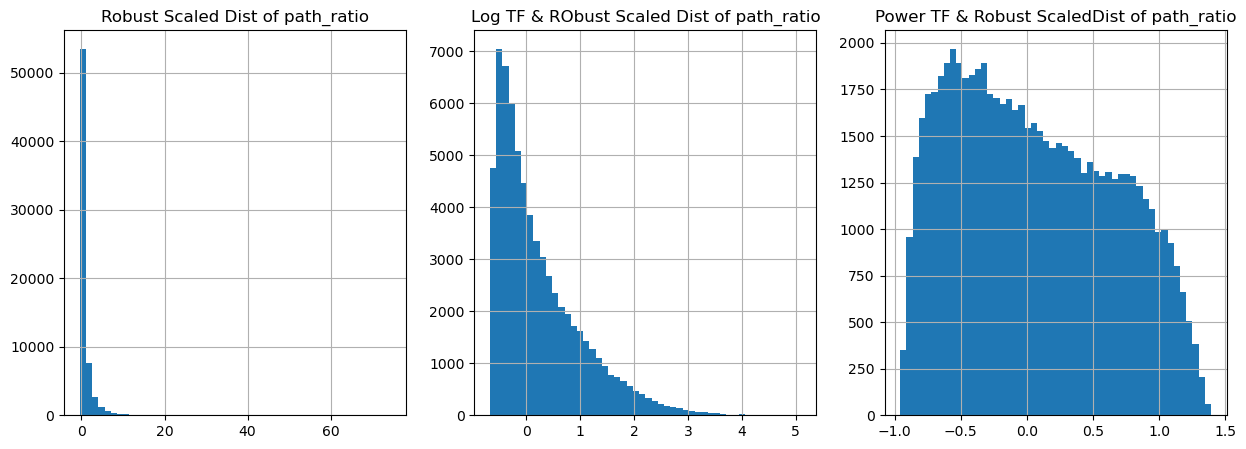

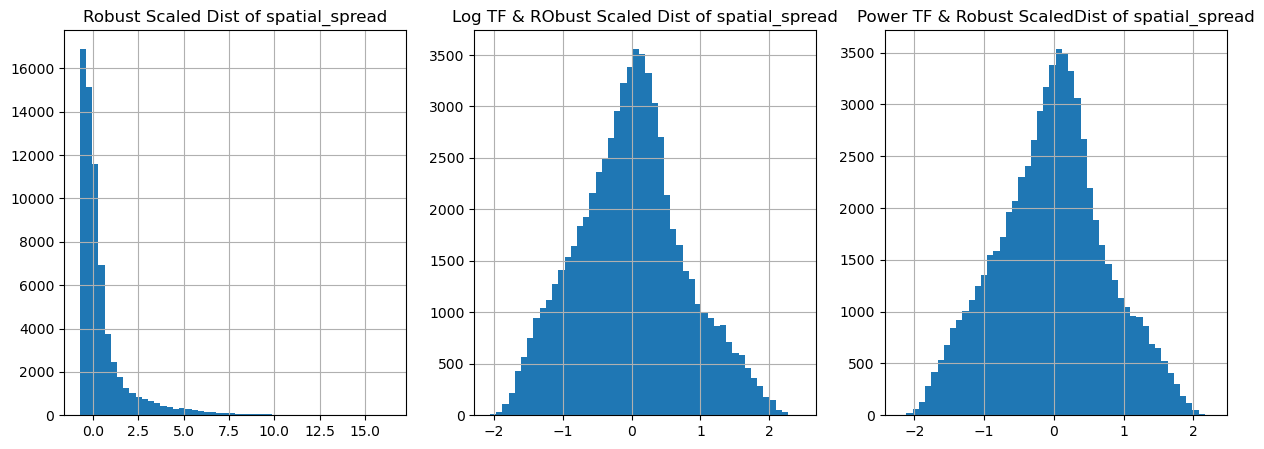

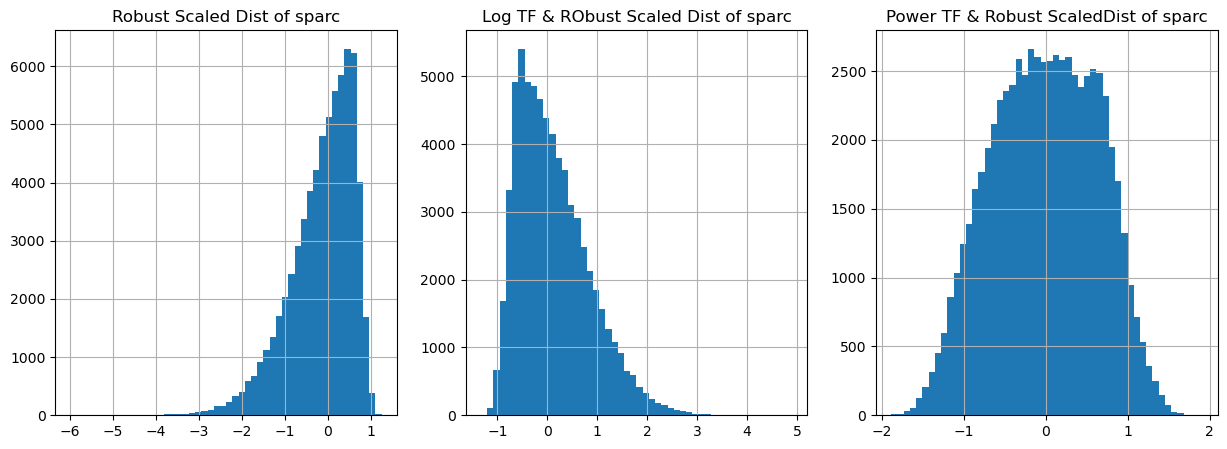

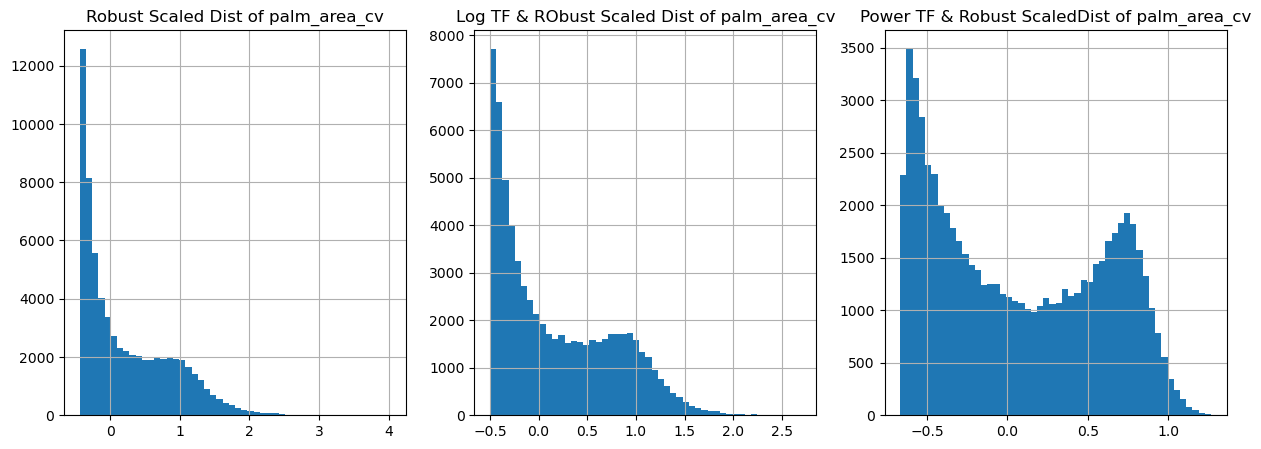

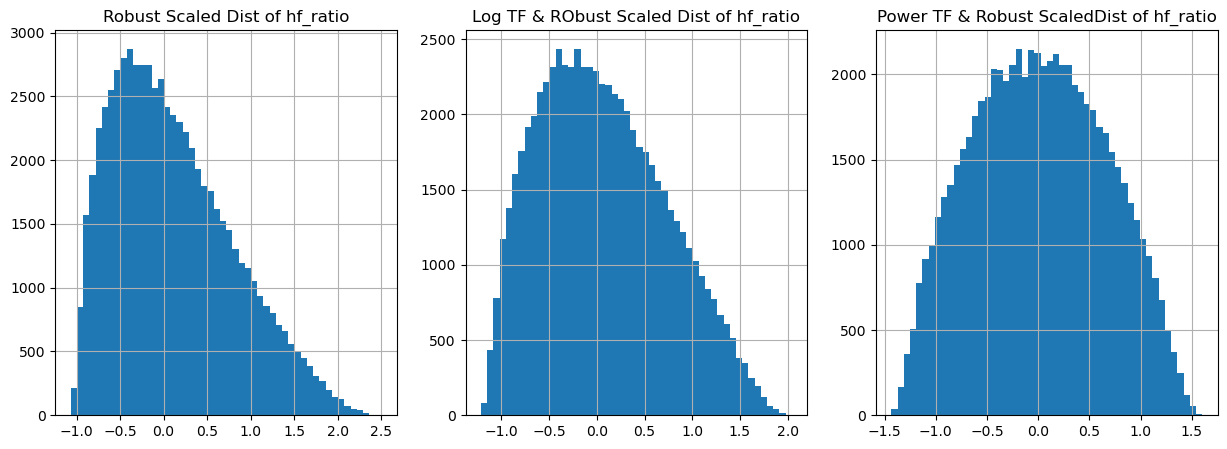

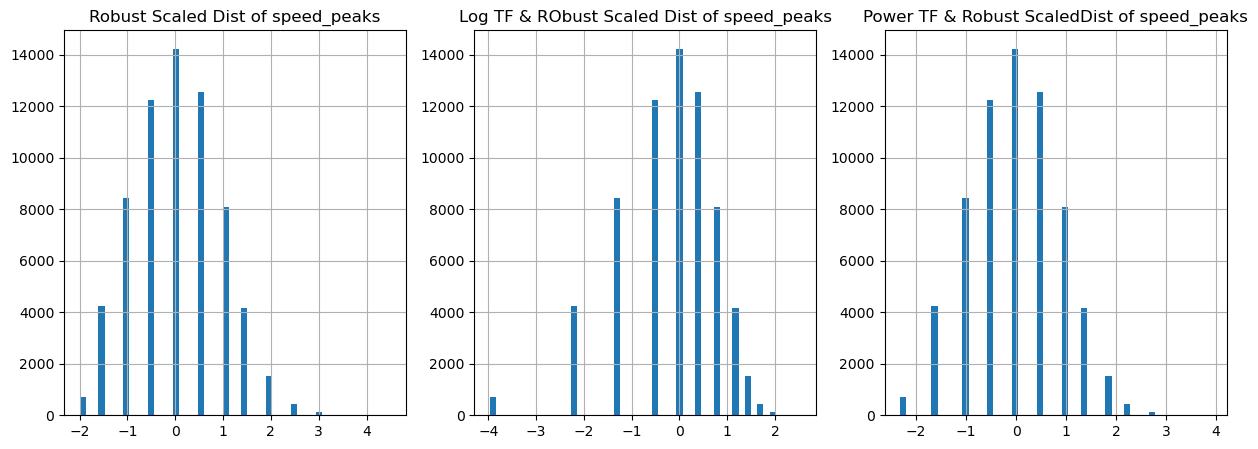

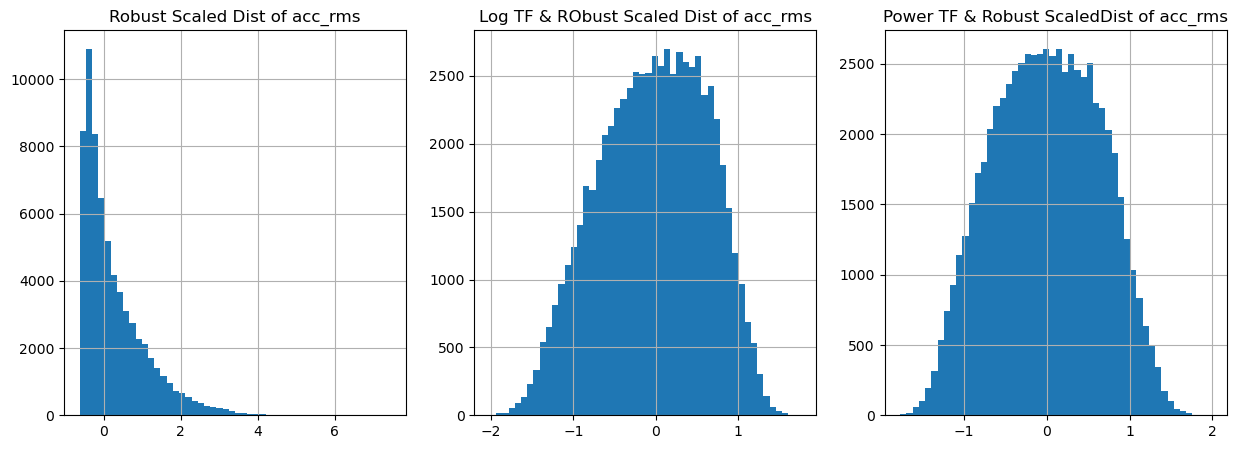

In [ ]:
# Visualize distributions of key features before clustering

from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import PowerTransformer

scaler = RobustScaler()
p_tf = PowerTransformer(method='yeo-johnson', standardize=False)

for feat in ['path_ratio', 'spatial_spread', 'sparc', 'palm_area_cv', 'hf_ratio', 'speed_peaks', 'acc_rms']: #['bimanual_sync', 'bimanual_ratio', 'bimanual_dist_mean', 'bimanual_dist_std']:#

    X = df_window_features[feat]
    X_scaled = scaler.fit_transform(X.values.reshape(-1, 1))

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.title(f"Robust Scaled Dist of {feat}")
    pd.Series(X_scaled.flatten()).hist(bins=50)

    plt.subplot(1, 3, 2)
    plt.title(f"Log TF & RObust Scaled Dist of {feat}")
    X_tf_scaled = scaler.fit_transform(df_window_features[feat].apply(lambda x: np.log1p(np.abs(x))).values.reshape(-1, 1))
    pd.Series(X_tf_scaled.flatten()).hist(bins=50)

    plt.subplot(1, 3, 3)
    plt.title(f"Power TF & Robust ScaledDist of {feat}")
    X_tf_scaled = scaler.fit_transform(p_tf.fit_transform(X.values.reshape(-1, 1)))
    pd.Series(X_tf_scaled.flatten()).hist(bins=50)

### **Start With Version Where the Clustering is Fitted on the Entire Data**
So there is some data leakage, but to get a general idea it is much faster

First cluster sensitivity analysis to evaluate how senstive the performance is to the predefined number of clusters.

The number of clusters resulting in the best performance is selected and used for interpretation of the kinematic bow features

In [42]:
def print_performance(summary, title):
    print(f"=== {title} ===")
    print(f"MAE: {summary['MAE']:.4f} ± {summary['MAE_STD']:.4f}")
    print(f"Spearman R: {summary['Spearman_R']:.4f} and R²: {summary['R2']:.4f}\n")

evaluator = LOSOEvaluator(EvaluationConfig(
    target_col="QRS_Overal",
    surgeon_col="Participant Number",
    video_col="video_id",
    device="cpu",
    seed=42,
))

In [82]:
n=3
# Define your settings
seeds = np.arange(n) * 42  # Add as many seeds as you want
cluster_range = range(8, 26, 1)

# Dictionary to store results for each seed
# Structure: {metric: {seed: [values_per_cluster]}}
results = {
    'MAE': {cluster: [] for cluster in cluster_range},
    'MAE_STD': {cluster: [] for cluster in cluster_range},
    'Spearman_R': {cluster: [] for cluster in cluster_range},
    'R2': {cluster: [] for cluster in cluster_range}
}

for n_cluster in cluster_range:    
    for seed in tqdm(seeds, desc=f"Evaluating seeds for {n_cluster} clusters"):
        #print("seed:", seed)
        # 1. Fit Vocabulary with current seed
        vocab = KinematicVocabulary(
            n_clusters=n_cluster, 
            random_state=seed, 
            model_type='kmeans', 
            n_init=10,
            feature_cols=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
            log_feats=['path_ratio', 'spatial_spread', 'sparc', 'palm_area_cv'],
        )

        vocab.fit(df_window)
        df_voc = vocab.transform(df_window)

        # 2. Prepare Data
        candidate_features = [col for col in df_voc.columns if col != 'video_id'] + ['Case_1', 'Case_2', 'Case_3']
        comb_df = pd.merge(df_pc1_features, df_voc, left_on='video_id', right_index=True)
        

        # 3. Evaluate
        res = evaluator.evaluate_tabular(
            df=comb_df,
            primary_features=pc1_features,
            extra_features=candidate_features,
            pca_components=[0],
            collect_weights=True,
            model=LassoCV(alphas=np.logspace(-1, 0.5, 30)),
            verbose=False
        )
        
        # 4. Store metrics
        summary = res['summary']
        results['MAE'][n_cluster].append(summary['MAE'])
        results['MAE_STD'][n_cluster].append(summary['MAE_STD'])
        results['Spearman_R'][n_cluster].append(summary['Spearman_R'])
        results['R2'][n_cluster].append(summary['R2'])
    
    summary = {metric: np.mean(results[metric][n_cluster]) for metric in results}
    print_performance(summary, f"{n_cluster} clusters - Average across seeds")


# --- Processing for Plotting ---
def get_stats(metric_dict):
    # Convert dict of lists to a 2D array: (seeds, n_clusters)
    arr = np.array([metric_dict[cluster] for cluster in cluster_range])
    return np.mean(arr, axis=0), np.std(arr, axis=0)

mae_mean, mae_std = get_stats(results['MAE'])
spearman_r_mean, spearman_r_std = get_stats(results['Spearman_R'])
r2_mean, r2_std = get_stats(results['R2'])

Evaluating seeds for 8 clusters: 100%|██████████| 3/3 [00:08<00:00,  2.92s/it]


=== 8 clusters - Average across seeds ===
MAE: 5.0692 ± 3.9433
Spearman R: 0.7213 and R²: 0.5239



Evaluating seeds for 9 clusters: 100%|██████████| 3/3 [00:07<00:00,  2.49s/it]


=== 9 clusters - Average across seeds ===
MAE: 4.8281 ± 3.9387
Spearman R: 0.7436 and R²: 0.5518



Evaluating seeds for 10 clusters: 100%|██████████| 3/3 [00:07<00:00,  2.64s/it]


...

=== 23 clusters - Average across seeds ===
MAE: 4.8137 ± 3.8419
Spearman R: 0.7490 and R²: 0.5621



Evaluating seeds for 24 clusters: 100%|██████████| 3/3 [00:12<00:00,  4.07s/it]


=== 24 clusters - Average across seeds ===
MAE: 4.8039 ± 3.8478
Spearman R: 0.7478 and R²: 0.5627



Evaluating seeds for 25 clusters: 100%|██████████| 3/3 [00:11<00:00,  3.90s/it]

=== 25 clusters - Average across seeds ===
MAE: 4.8383 ± 3.7917
Spearman R: 0.7495 and R²: 0.5638



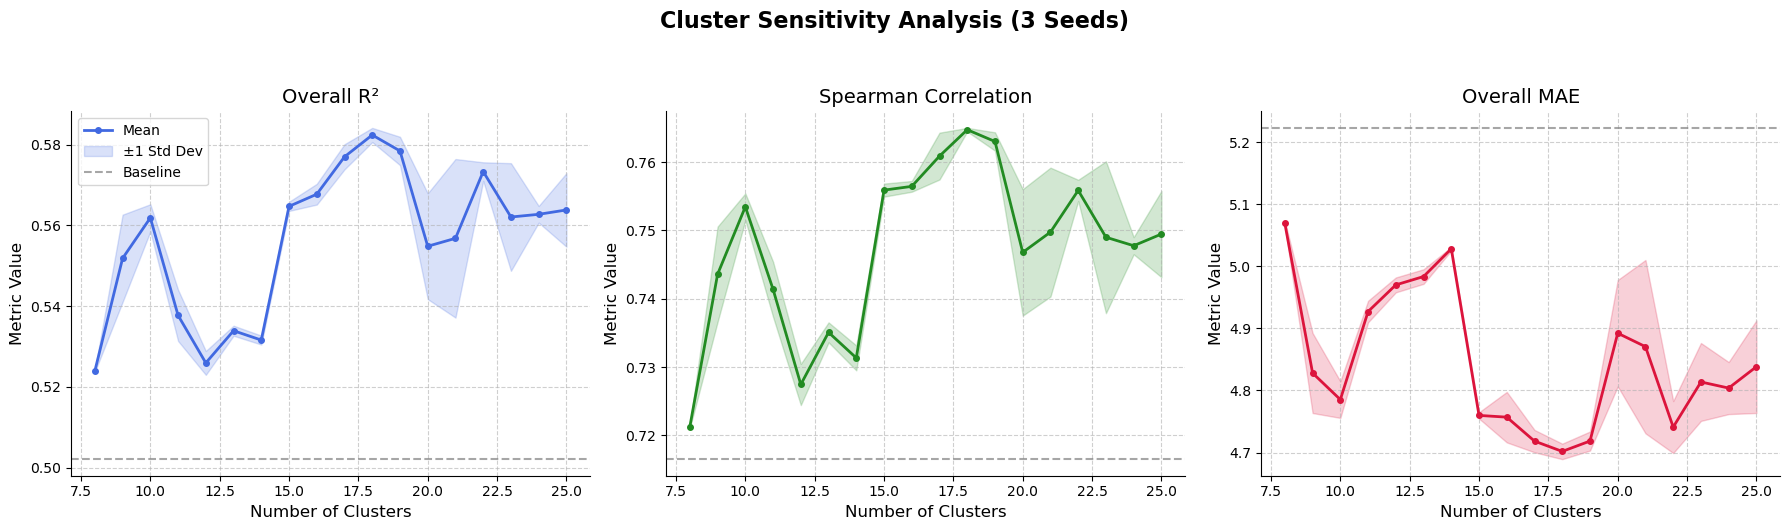

In [83]:
plot_sensitivity_results(cluster_range, results)

In [44]:
#df_window['spatial_spread'] = df_window['spatial_spread'].apply(lambda x: np.log1p(np.abs(x)))

kin_voc = KinematicVocabulary(n_clusters=18, random_state=42, model_type='kmeans', n_init=20,
                          feature_cols=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                          log_feats=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                          )

"""df_bimanual = df_window_features[df_window_features['bimanual_dist_mean'].notna()]
vocab = KinematicVocabulary(n_clusters=20, random_state=42, model_type='kmeans', n_init=5,
                            feature_cols=['total_path', 'path_ratio', 'spatial_spread', 'sparc', 'palm_area_cv', 'bimanual_dist_mean', 'bimanual_sync'],
                            log_feats=['total_path', 'path_ratio', 'spatial_spread', 'sparc'])
df_window = df_bimanual.copy()"""

kin_voc.fit(df_window)
df_voc = kin_voc.transform(df_window)
df_voc.head(5)


,SurgeMe_0,SurgeMe_1,SurgeMe_2,SurgeMe_3,SurgeMe_4,SurgeMe_5,SurgeMe_6,SurgeMe_7,SurgeMe_8,SurgeMe_9,SurgeMe_10,SurgeMe_11,SurgeMe_12,SurgeMe_13,SurgeMe_14,SurgeMe_15,SurgeMe_16,SurgeMe_17
"(2024-01-15_13-18-23, 1)",0.064392,0.053325,0.052920,0.061906,0.059028,0.075685,0.029873,0.056862,0.054602,0.029532,0.047858,0.048791,0.036120,0.077215,0.063762,0.072079,0.053467,0.062584
"(2024-01-15_13-37-36, 1)",0.056901,0.051225,0.051396,0.060754,0.062397,0.074106,0.031029,0.054702,0.058143,0.037044,0.049772,0.044038,0.043061,0.071918,0.061847,0.070719,0.057198,0.063749
"(2024-01-15_14-03-23, 1)",0.052901,0.054427,0.074446,0.056752,0.056197,0.062662,0.045781,0.064755,0.048282,0.033466,0.051783,0.041412,0.055748,0.061323,0.066413,0.055652,0.065794,0.052205
"(2024-01-15_14-32-45, 2)",0.056141,0.058745,0.047293,0.058828,0.056760,0.082467,0.025697,0.054202,0.060452,0.031478,0.052763,0.039075,0.030634,0.079725,0.064412,0.079685,0.049739,0.071904
"(2024-01-15_15-05-31, 2)",0.055203,0.058845,0.046434,0.063564,0.056418,0.080418,0.025312,0.055843,0.060445,0.028451,0.051941,0.040357,0.028444,0.077945,0.066516,0.080926,0.049217,0.073721


In [45]:
pearson_corrs, spearman_corrs = get_top_correlations(df_voc, df_scores['QRS_Overal'].to_list())

Top 15 features by Pearson correlation:
SurgeMe_4                      Pearson r = -0.4999, Spearman rho = -0.4775
SurgeMe_5                      Pearson r = -0.4998, Spearman rho = -0.4827
SurgeMe_2                      Pearson r = 0.4819, Spearman rho = 0.4759
SurgeMe_13                     Pearson r = -0.4804, Spearman rho = -0.4426
SurgeMe_12                     Pearson r = 0.4549, Spearman rho = 0.4649
SurgeMe_6                      Pearson r = 0.3953, Spearman rho = 0.4499
SurgeMe_15                     Pearson r = -0.3691, Spearman rho = -0.3708
SurgeMe_0                      Pearson r = -0.3438, Spearman rho = -0.2747
SurgeMe_16                     Pearson r = 0.3345, Spearman rho = 0.3158
SurgeMe_8                      Pearson r = -0.2697, Spearman rho = -0.2699
SurgeMe_17                     Pearson r = -0.2668, Spearman rho = -0.2578
SurgeMe_7                      Pearson r = 0.2580, Spearman rho = 0.2626
SurgeMe_3                      Pearson r = -0.2557, Spearman rho = -0.

In [46]:
# check cluster centroids for top positive and negative predictors
top_2_positive = np.argsort(pearson_corrs)[-9:]
top_2_negative = np.argsort(pearson_corrs)[:9]
if kin_voc.model_type == 'kmeans':
    centroids = kin_voc.model.cluster_centers_
else:
    centroids = kin_voc.model.means_
feature_names = kin_voc.feature_cols

print("--- Negative Predictors (Novice Moves) ---")
for idx in top_2_negative:
    print(f"Cluster {idx}, (corr: {round(pearson_corrs[idx], 3)}): {dict(zip(feature_names, np.round(centroids[idx], 2)))}")

print("\n--- Positive Predictors (Expert Moves) ---")
for idx in reversed(top_2_positive):
    print(f"Cluster {idx}, (corr: {round(pearson_corrs[idx], 3)}): {dict(zip(feature_names, np.round(centroids[idx], 2)))}")

--- Negative Predictors (Novice Moves) ---
Cluster 4, (corr: -0.5): {'path_ratio': np.float64(-0.18), 'spatial_spread': np.float64(0.97), 'palm_area_cv': np.float64(0.25), 'sparc': np.float64(0.61)}
Cluster 5, (corr: -0.5): {'path_ratio': np.float64(-0.19), 'spatial_spread': np.float64(0.08), 'palm_area_cv': np.float64(-0.38), 'sparc': np.float64(0.34)}
Cluster 13, (corr: -0.48): {'path_ratio': np.float64(-0.32), 'spatial_spread': np.float64(0.53), 'palm_area_cv': np.float64(-0.31), 'sparc': np.float64(-0.48)}
Cluster 15, (corr: -0.369): {'path_ratio': np.float64(-0.25), 'spatial_spread': np.float64(-0.28), 'palm_area_cv': np.float64(-0.45), 'sparc': np.float64(-0.48)}
Cluster 0, (corr: -0.344): {'path_ratio': np.float64(-0.39), 'spatial_spread': np.float64(1.39), 'palm_area_cv': np.float64(-0.14), 'sparc': np.float64(-0.48)}
Cluster 8, (corr: -0.27): {'path_ratio': np.float64(-0.05), 'spatial_spread': np.float64(-0.56), 'palm_area_cv': np.float64(-0.41), 'sparc': np.float64(1.06)}
Clu

In [47]:
top_positive = [f'SurgeMe_{idx}' for idx in top_2_positive]
top_negative = [f'SurgeMe_{idx}' for idx in top_2_negative]
top = top_positive + top_negative

df_voc[top].corr()

,SurgeMe_1,SurgeMe_10,SurgeMe_14,SurgeMe_9,SurgeMe_7,SurgeMe_16,SurgeMe_6,SurgeMe_12,SurgeMe_2,SurgeMe_4,SurgeMe_5,SurgeMe_13,SurgeMe_15,SurgeMe_0,SurgeMe_8,SurgeMe_17,SurgeMe_3,SurgeMe_11
SurgeMe_1,1.000000,0.838603,-0.225094,0.437796,-0.155093,-0.211314,0.027487,0.021091,-0.028468,-0.733904,0.041132,-0.219817,0.109369,-0.529855,0.457061,0.419209,-0.736450,-0.603433
SurgeMe_10,0.838603,1.000000,-0.279582,0.800850,-0.343889,-0.022291,-0.022161,0.209372,0.012493,-0.732174,-0.060646,-0.368593,-0.033165,-0.513986,0.529764,0.364435,-0.805714,-0.517160
SurgeMe_14,-0.225094,-0.279582,1.000000,-0.083006,0.358325,0.564116,0.046494,0.108719,0.367768,-0.044491,-0.316848,-0.301617,-0.220397,-0.410754,-0.315970,-0.221102,0.468182,-0.210003
SurgeMe_9,0.437796,0.800850,-0.083006,1.000000,-0.275969,0.342911,-0.003387,0.407897,0.159756,-0.502916,-0.217681,-0.499123,-0.252593,-0.515470,0.372753,0.103866,-0.602167,-0.438341
SurgeMe_7,-0.155093,-0.343889,0.358325,-0.275969,1.000000,0.595414,0.848228,0.600505,0.810081,-0.022351,-0.745798,-0.606118,-0.752057,-0.367983,-0.829359,-0.823405,0.162917,-0.055296
SurgeMe_16,-0.211314,-0.022291,0.564116,0.342911,0.595414,1.000000,0.541064,0.789649,0.840691,-0.142794,-0.778182,-0.798526,-0.804880,-0.574199,-0.568720,-0.717861,0.026557,-0.228738
SurgeMe_6,0.027487,-0.022161,0.046494,-0.003387,0.848228,0.541064,1.000000,0.814865,0.874086,-0.311891,-0.852981,-0.748998,-0.830984,-0.415340,-0.753722,-0.802446,-0.193803,-0.070087
SurgeMe_12,0.021091,0.209372,0.108719,0.407897,0.600505,0.789649,0.814865,1.000000,0.906328,-0.396187,-0.894592,-0.880823,-0.886839,-0.536592,-0.614520,-0.768939,-0.315955,-0.167066
SurgeMe_2,-0.028468,0.012493,0.367768,0.159756,0.810081,0.840691,0.874086,0.906328,1.000000,-0.361011,-0.933150,-0.877726,-0.902533,-0.580473,-0.752580,-0.827936,-0.147436,-0.191055
SurgeMe_4,-0.733904,-0.732174,-0.044491,-0.502916,-0.022351,-0.142794,-0.311891,-0.396187,-0.361011,1.000000,0.312822,0.492947,0.143294,0.695710,-0.162190,-0.141889,0.740759,0.612045


In [48]:

# combine the global and bow features
comb_df = pd.merge(df_pc1_features, df_voc, left_on='video_id', right_index=True)

pc1_features = [f for f in df_pc1_features.columns if '(R)' in f]
candidate_features = df_voc.columns.tolist()

# add case one-hotting to the combined df
df_case_onehot = pd.get_dummies(df_pc1_features['Case_Number'], prefix='Case').astype(int)

if not any('Case_1' in col for col in comb_df.columns):
    comb_df = pd.concat([comb_df, df_case_onehot], axis=1)

df_residuals_loso = loso_residual_analysis(comb_df, pc1_features, candidate_features, base_features=[], top_n=1, perform_shuffle=False)
df_residuals_loso

,Feature,Partial_R2_mean,Partial_R2_std,Partial_R2_min,Resid_Corr_mean,Selection_Stability
12,SurgeMe_4,0.145322,0.013137,0.119216,-0.364553,1.0
10,SurgeMe_2,0.125510,0.009800,0.101372,0.339535,0.0
13,SurgeMe_5,0.114934,0.010660,0.094123,-0.319968,0.0
5,SurgeMe_13,0.090561,0.011176,0.068598,-0.284019,0.0
0,SurgeMe_0,0.089463,0.011982,0.065108,-0.297147,0.0
4,SurgeMe_12,0.081448,0.008539,0.064077,0.271914,0.0
6,SurgeMe_14,0.073425,0.010482,0.056292,0.271927,0.0
14,SurgeMe_6,0.073202,0.010163,0.058473,0.264856,0.0
8,SurgeMe_16,0.055244,0.007130,0.043739,0.233037,0.0
16,SurgeMe_8,0.052872,0.008157,0.037742,-0.230470,0.0


In [49]:
if not [any('Case_1' in col for col in comb_df.columns)]:
    comb_df = pd.concat([comb_df, df_case_onehot], axis=1)
    candidate_features += list(df_case_onehot.columns)

evaluator = LOSOEvaluator(EvaluationConfig(
    target_col="QRS_Overal",
    surgeon_col="Participant Number",
    video_col="video_id",
    device="cpu",
    seed=42,
))

results = evaluator.evaluate_tabular(
    df=comb_df,
    primary_features=pc1_features,
    extra_features=candidate_features,
    pca_components=[0],
    collect_weights=True,
    model=LassoCV(alphas=np.logspace(-1, 0.5, 30)),
    verbose=False
)

print_performance(results['summary'], "LassoCV PC1 + casetypes + spatial spread median")
print(results['weights'])

=== LassoCV PC1 + casetypes + spatial spread median ===
MAE: 4.6847 ± 3.7446
Spearman R: 0.7649 and R²: 0.5848

       Feature  Average_Weight  Std_Weight
0         bias       49.938586    0.308361
1          PC1       -4.984802    0.169462
2    SurgeMe_0        0.000000    0.000000
3    SurgeMe_1        0.000000    0.000000
4    SurgeMe_2        0.000000    0.000000
5    SurgeMe_3       -0.015140    0.080112
6    SurgeMe_4       -2.698553    0.141834
7    SurgeMe_5       -0.079530    0.152959
8    SurgeMe_6        0.000000    0.000000
9    SurgeMe_7        0.000000    0.000000
10   SurgeMe_8       -1.466834    0.184679
11   SurgeMe_9        0.000000    0.000000
12  SurgeMe_10        0.000000    0.000000
13  SurgeMe_11        0.000000    0.000000
14  SurgeMe_12        0.000000    0.000000
15  SurgeMe_13        0.000000    0.000000
16  SurgeMe_14        0.892130    0.155049
17  SurgeMe_15        0.000000    0.000000
18  SurgeMe_16        0.000000    0.000000
19  SurgeMe_17        0.0000

In [50]:
# ElastiNetCV for comparison
results = evaluator.evaluate_tabular(
    df=comb_df,
    primary_features=pc1_features,
    extra_features=candidate_features,
    pca_components=[0],
    collect_weights=True,
    model=ElasticNetCV(l1_ratio=[0.2, 0.5, 0.7, 0.9, 0.95, 0.99], alphas=np.logspace(-1, 0.5, 30)),
    verbose=False
)

print_performance(results['summary'], "ElasticNetCV PC1 + casetypes + spatial spread median")
print(results['weights'])

=== ElasticNetCV PC1 + casetypes + spatial spread median ===
MAE: 4.7003 ± 3.7744
Spearman R: 0.7638 and R²: 0.5806

       Feature  Average_Weight  Std_Weight
0         bias       49.938586    0.308361
1          PC1       -4.905021    0.232342
2    SurgeMe_0        0.000000    0.000000
3    SurgeMe_1        0.000000    0.000000
4    SurgeMe_2        0.000000    0.000000
5    SurgeMe_3       -0.022544    0.089069
6    SurgeMe_4       -2.645395    0.177853
7    SurgeMe_5       -0.197507    0.262789
8    SurgeMe_6        0.000000    0.000000
9    SurgeMe_7        0.000000    0.000000
10   SurgeMe_8       -1.379527    0.261918
11   SurgeMe_9        0.000000    0.000000
12  SurgeMe_10        0.000000    0.000000
13  SurgeMe_11        0.000000    0.000000
14  SurgeMe_12        0.000000    0.000000
15  SurgeMe_13        0.000000    0.000000
16  SurgeMe_14        0.895867    0.152685
17  SurgeMe_15        0.000000    0.000000
18  SurgeMe_16        0.000000    0.000000
19  SurgeMe_17        0

## Bow Features Alone
- How well can BoW features alone explain skill scores?

- Does the best number of clusters match that of the hybrid BoW + pc1 model?

In [51]:
n=3
# Define your settings
seeds = np.arange(n) * 42  # Add as many seeds as you want
cluster_range = range(8, 26, 1)

# Dictionary to store results for each seed
# Structure: {metric: {seed: [values_per_cluster]}}
results = {
    'MAE': {cluster: [] for cluster in cluster_range},
    'MAE_STD': {cluster: [] for cluster in cluster_range},
    'Spearman_R': {cluster: [] for cluster in cluster_range},
    'R2': {cluster: [] for cluster in cluster_range}
}

for n_cluster in cluster_range:    
    for seed in tqdm(seeds, desc=f"Evaluating seeds for {n_cluster} clusters"):
        #print("seed:", seed)
        # 1. Fit Vocabulary with current seed
        vocab = KinematicVocabulary(
            n_clusters=n_cluster, 
            random_state=seed, 
            model_type='kmeans', 
            n_init=10,
            feature_cols=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
            log_feats=['path_ratio', 'spatial_spread', 'sparc', 'palm_area_cv'],
        )

        vocab.fit(df_window)
        df_voc = vocab.transform(df_window)

        # 2. Prepare Data
        candidate_features = [col for col in df_voc.columns if col != 'video_id']
        comb_df = pd.merge(df_pc1_features, df_voc, left_on='video_id', right_index=True)
        

        # 3. Evaluate
        res = evaluator.evaluate_tabular(
            df=comb_df,
            primary_features=[],
            extra_features=candidate_features,
            collect_weights=True,
            model=LassoCV(alphas=np.logspace(-1, 0.5, 30)),
            verbose=False
        )
        
        # 4. Store metrics
        summary = res['summary']
        results['MAE'][n_cluster].append(summary['MAE'])
        results['MAE_STD'][n_cluster].append(summary['MAE_STD'])
        results['Spearman_R'][n_cluster].append(summary['Spearman_R'])
        results['R2'][n_cluster].append(summary['R2'])
    
    summary = {metric: np.mean(results[metric][n_cluster]) for metric in results}
    print_performance(summary, f"{n_cluster} clusters - Average across seeds")


# --- Processing for Plotting ---
def get_stats(metric_dict):
    # Convert dict of lists to a 2D array: (seeds, n_clusters)
    arr = np.array([metric_dict[cluster] for cluster in cluster_range])
    return np.mean(arr, axis=0), np.std(arr, axis=0)

mae_mean, mae_std = get_stats(results['MAE'])
spearman_r_mean, spearman_r_std = get_stats(results['Spearman_R'])
r2_mean, r2_std = get_stats(results['R2'])

Evaluating seeds for 8 clusters: 100%|██████████| 3/3 [00:06<00:00,  2.27s/it]


=== 8 clusters - Average across seeds ===
MAE: 7.3610 ± 4.6468
Spearman R: 0.3293 and R²: 0.1254



Evaluating seeds for 9 clusters: 100%|██████████| 3/3 [00:06<00:00,  2.16s/it]


=== 9 clusters - Average across seeds ===
MAE: 6.5058 ± 4.3926
Spearman R: 0.5175 and R²: 0.2882



Evaluating seeds for 10 clusters: 100%|██████████| 3/3 [00:06<00:00,  2.20s/it]


...

=== 23 clusters - Average across seeds ===
MAE: 6.7552 ± 4.4750
Spearman R: 0.4415 and R²: 0.2420



Evaluating seeds for 24 clusters:   0%|          | 0/3 [00:00<?, ?it/s]/Users/finnweikert/opt/anaconda3/envs/env-ml/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.251e-01, tolerance: 6.559e-01
  model = cd_fast.enet_coordinate_descent_gram(
Evaluating seeds for 24 clusters:  33%|███▎      | 1/3 [00:03<00:06,  3.22s/it]/Users/finnweikert/opt/anaconda3/envs/env-ml/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.299e-01, tolerance: 5.798e-01
  model = cd_fast.enet_coordinate_descent_gram(
Evaluating seeds for 24 clusters: 100%|██████████| 3/3 [00:10<00:00,  3.41

=== 24 clusters - Average across seeds ===
MAE: 6.7540 ± 4.4649
Spearman R: 0.4432 and R²: 0.2434



Evaluating seeds for 25 clusters:  67%|██████▋   | 2/3 [00:10<00:05,  5.08s/it]/Users/finnweikert/opt/anaconda3/envs/env-ml/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.038e-01, tolerance: 6.518e-01
  model = cd_fast.enet_coordinate_descent_gram(
Evaluating seeds for 25 clusters: 100%|██████████| 3/3 [00:14<00:00,  4.73s/it]

=== 25 clusters - Average across seeds ===
MAE: 6.7323 ± 4.4349
Spearman R: 0.4509 and R²: 0.2498



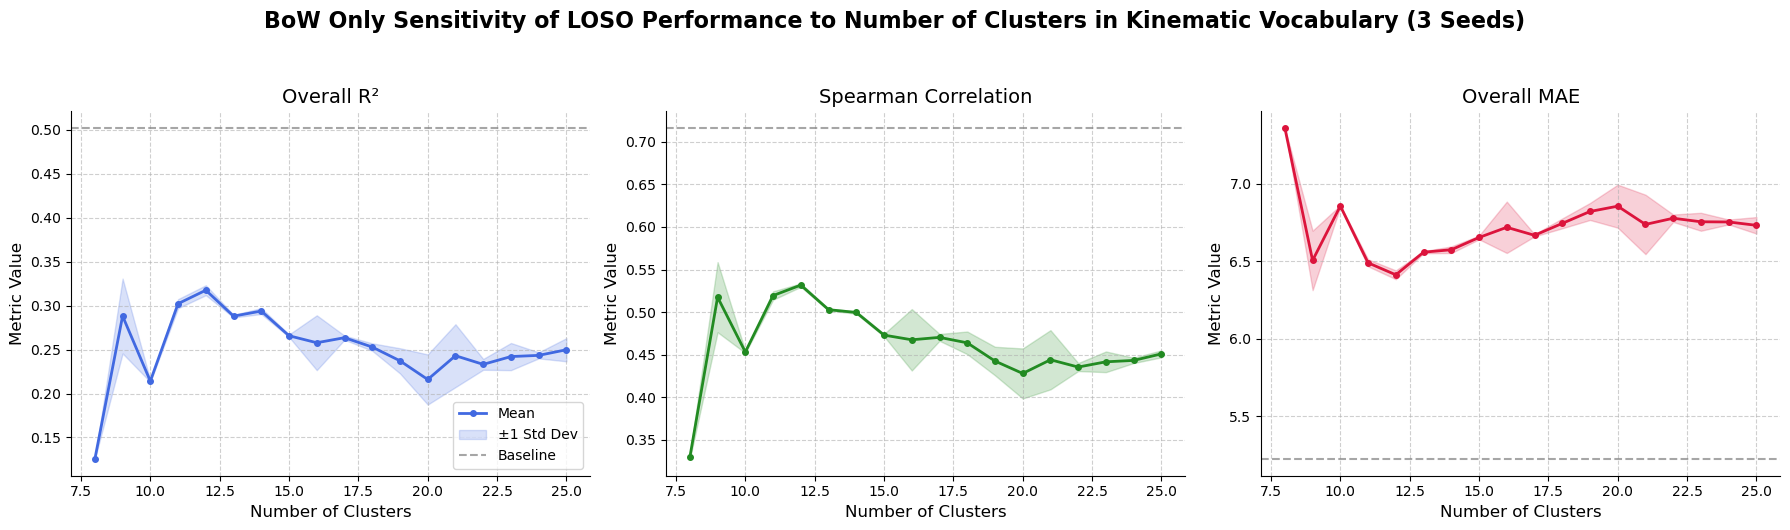

In [53]:
plot_sensitivity_results(cluster_range, results, title="BoW Only Sensitivity of LOSO Performance to Number of Clusters in Kinematic Vocabulary")

# Now Kmeans Fitted in LOSO leakage-free

In [54]:
n=3
# Define your settings
seeds = np.arange(n) * 42  # Add as many seeds as you want
cluster_range = range(8, 26, 1)

# Dictionary to store results for each seed
# Structure: {metric: {seed: [values_per_cluster]}}
results = {
    'MAE': {cluster: [] for cluster in cluster_range},
    'MAE_STD': {cluster: [] for cluster in cluster_range},
    'Spearman_R': {cluster: [] for cluster in cluster_range},
    'R2': {cluster: [] for cluster in cluster_range}
}

for n_cluster in cluster_range:    
    for seed in tqdm(seeds, desc=f"Evaluating seeds for {n_cluster} clusters"):
        #print("seed:", seed)
        # 1. Fit Vocabulary with current seed
        vocab = KinematicVocabulary(
            n_clusters=n_cluster, 
            random_state=seed, 
            model_type='kmeans', 
            n_init=10,
            feature_cols=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
            log_feats=['path_ratio', 'spatial_spread', 'sparc', 'palm_area_cv'],
        )

        # 3. Evaluate
        res = evaluator.evaluate_vocabulary(
            df_pc1_features,
            df_window,
            vocab,
            model=LassoCV(alphas=np.logspace(-1, 0.5, 20)),
            primary_features=pc1_features,
            bow_features=[col for col in df_voc.columns if col != 'video_id'],
            extra_features=['Case_1', 'Case_2', 'Case_3'],
            leakage_free=True,
            use_baseline=True,
        )
        
        # 4. Store metrics
        summary = res['summary']
        results['MAE'][n_cluster].append(summary['MAE'])
        results['MAE_STD'][n_cluster].append(summary['MAE_STD'])
        results['Spearman_R'][n_cluster].append(summary['Spearman_R'])
        results['R2'][n_cluster].append(summary['R2'])
    
    summary = {metric: np.mean(results[metric][n_cluster]) for metric in results}
    print_performance(summary, f"{n_cluster} clusters - Average across seeds")


# --- Processing for Plotting ---
def get_stats(metric_dict):
    # Convert dict of lists to a 2D array: (seeds, n_clusters)
    arr = np.array([metric_dict[cluster] for cluster in cluster_range])
    return np.mean(arr, axis=0), np.std(arr, axis=0)

mae_mean, mae_std = get_stats(results['MAE'])
spearman_r_mean, spearman_r_std = get_stats(results['Spearman_R'])
r2_mean, r2_std = get_stats(results['R2'])

Evaluating seeds for 8 clusters: 100%|██████████| 3/3 [01:41<00:00, 33.83s/it]


=== 8 clusters - Average across seeds ===
MAE: 5.0919 ± 3.9249
Spearman R: 0.7226 and R²: 0.5229



Evaluating seeds for 9 clusters: 100%|██████████| 3/3 [01:57<00:00, 39.14s/it]


=== 9 clusters - Average across seeds ===
MAE: 4.7954 ± 3.8533
Spearman R: 0.7512 and R²: 0.5632



Evaluating seeds for 10 clusters:  67%|██████▋   | 2/3 [02:17<01:08, 68.75s/it]


KeyboardInterrupt: 

In [ ]:
plot_sensitivity_results(cluster_range, results)

**Thesis Result:** With k=18 and many inits Thesis Result

In [87]:
# with K = 18 !THESIS RESULT!
seed = 42
print('seed:', seed)
vocab = KinematicVocabulary(n_clusters=18, random_state=seed, model_type='kmeans', n_init=20,
                            feature_cols=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                            log_feats=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                            power_feats=None)


res = evaluator.evaluate_vocabulary(
    df_pc1_features,
    df_window,
    vocab,
    model=LassoCV(alphas=np.logspace(-1, 0.5, 30)),
    primary_features=pc1_features,
    bow_features=['SurgeMe_' + str(i) for i in range(18)],
    extra_features=['Case_1', 'Case_2', 'Case_3'],
    leakage_free=True,
    use_baseline=True,
)

summary = res['summary']
print_performance(summary, f"18 Clusters - Results")

all_fold_centroids = res["fold_centroids"]

seed: 42


Vocabulary LOSO: 100%|██████████| 28/28 [01:18<00:00,  2.80s/it]

=== 18 Clusters - Results ===
MAE: 4.6950 ± 3.7459
Spearman R: 0.7642 and R²: 0.5836



# Align Fold Centroids To A Global Template

In [75]:
# do different seed produce very similar global scale clusters
vocab_ref = KinematicVocabulary(n_clusters=18, random_state=42, model_type='kmeans', n_init=50,
                          feature_cols=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                          log_feats=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                          )

vocab_ref.fit(df_window)

global_centers = vocab_ref.model.cluster_centers_

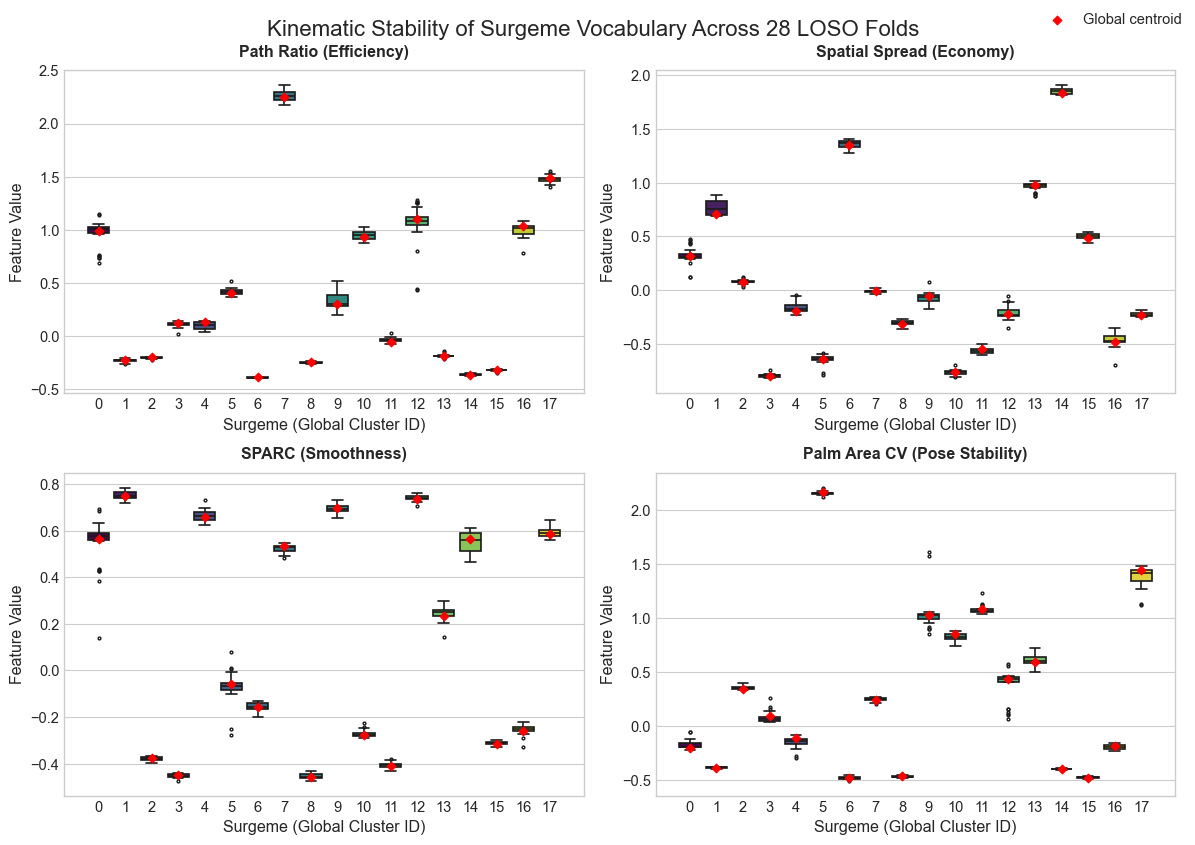

In [76]:
global_centers = vocab_ref.model.cluster_centers_
df_stability = align_fold_centroids(global_centers, all_fold_centroids)

# Let's look at 'sparc' stability across the 18 clusters
plot_surgeme_stability(df_stability, global_centers)

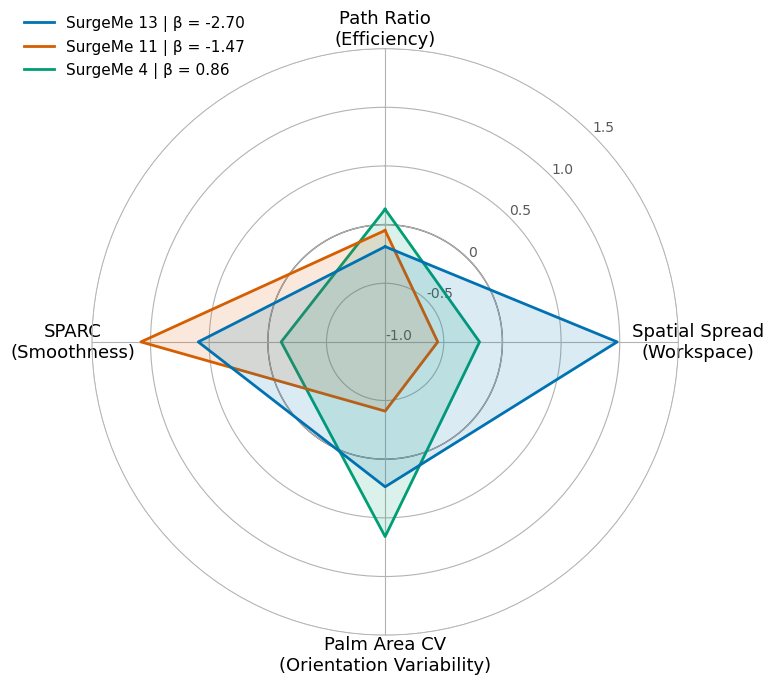

In [77]:
feat_names = [
     'Path Ratio\n(Efficiency)', 
     'Spatial Spread\n(Workspace)', 
     'Palm Area CV\n(Orientation Variability)', 
     'SPARC\n(Smoothness)'
 ]

clusters_to_show = [
     {'id': 13, 'label': 'Exploratory Motion', 'coef': -2.70},
     {'id': 11, 'label': 'Smooth Manipulation', 'coef': -1.47},
     {'id': 4,  'label': 'Stabilization', 'coef': 0.86}
]

plot_surgeme_radar(global_centers, feat_names, clusters_to_show)

### **With Velocity Correlation**

In [ ]:
df_pc1_features.head()

In [79]:
n=3
# Define your settings
seeds = np.arange(n) * 42  # Add as many seeds as you want
cluster_range = range(8, 26, 1)

# Dictionary to store results for each seed
# Structure: {metric: {seed: [values_per_cluster]}}
results = {
    'MAE': {cluster: [] for cluster in cluster_range},
    'MAE_STD': {cluster: [] for cluster in cluster_range},
    'Spearman_R': {cluster: [] for cluster in cluster_range},
    'R2': {cluster: [] for cluster in cluster_range}
}

for n_cluster in cluster_range:    
    for seed in tqdm(seeds, desc=f"Evaluating seeds for {n_cluster} clusters"):
        #print("seed:", seed)
        # 1. Fit Vocabulary with current seed
        vocab = KinematicVocabulary(
            n_clusters=n_cluster, 
            random_state=seed, 
            model_type='kmeans', 
            n_init=10,
            feature_cols=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
            log_feats=['path_ratio', 'spatial_spread', 'sparc', 'palm_area_cv'],
        )

        vocab.fit(df_window)
        df_voc = vocab.transform(df_window)

        # 2. Prepare Data
        candidate_features = [col for col in df_voc.columns if col != 'video_id'] + ['Case_1', 'Case_2', 'Case_3'] + ['Velocity corr.']
        comb_df = pd.merge(df_pc1_features, df_voc, left_on='video_id', right_index=True)
        

        # 3. Evaluate
        res = evaluator.evaluate_tabular(
            df=comb_df,
            primary_features=pc1_features,
            extra_features=candidate_features,
            pca_components=[0],
            collect_weights=True,
            model=LassoCV(alphas=np.logspace(-1, 0.5, 30)),
            verbose=False
        )
        
        # 4. Store metrics
        summary = res['summary']
        results['MAE'][n_cluster].append(summary['MAE'])
        results['MAE_STD'][n_cluster].append(summary['MAE_STD'])
        results['Spearman_R'][n_cluster].append(summary['Spearman_R'])
        results['R2'][n_cluster].append(summary['R2'])
    
    summary = {metric: np.mean(results[metric][n_cluster]) for metric in results}
    print_performance(summary, f"{n_cluster} clusters - Average across seeds")


# --- Processing for Plotting ---
def get_stats(metric_dict):
    # Convert dict of lists to a 2D array: (seeds, n_clusters)
    arr = np.array([metric_dict[cluster] for cluster in cluster_range])
    return np.mean(arr, axis=0), np.std(arr, axis=0)

mae_mean, mae_std = get_stats(results['MAE'])
spearman_r_mean, spearman_r_std = get_stats(results['Spearman_R'])
r2_mean, r2_std = get_stats(results['R2'])

Evaluating seeds for 8 clusters: 100%|██████████| 3/3 [00:11<00:00,  3.90s/it]


=== 8 clusters - Average across seeds ===
MAE: 4.9168 ± 3.6383
Spearman R: 0.7602 and R²: 0.5682



Evaluating seeds for 9 clusters: 100%|██████████| 3/3 [00:09<00:00,  3.07s/it]


=== 9 clusters - Average across seeds ===
MAE: 4.7647 ± 3.6741
Spearman R: 0.7817 and R²: 0.5820



Evaluating seeds for 10 clusters: 100%|██████████| 3/3 [00:09<00:00,  3.17s/it]


...

=== 23 clusters - Average across seeds ===
MAE: 4.9038 ± 3.6216
Spearman R: 0.7660 and R²: 0.5709



Evaluating seeds for 24 clusters: 100%|██████████| 3/3 [00:11<00:00,  3.78s/it]


=== 24 clusters - Average across seeds ===
MAE: 4.9011 ± 3.6074
Spearman R: 0.7680 and R²: 0.5725



Evaluating seeds for 25 clusters: 100%|██████████| 3/3 [00:11<00:00,  3.88s/it]

=== 25 clusters - Average across seeds ===
MAE: 4.9440 ± 3.5605
Spearman R: 0.7682 and R²: 0.5715



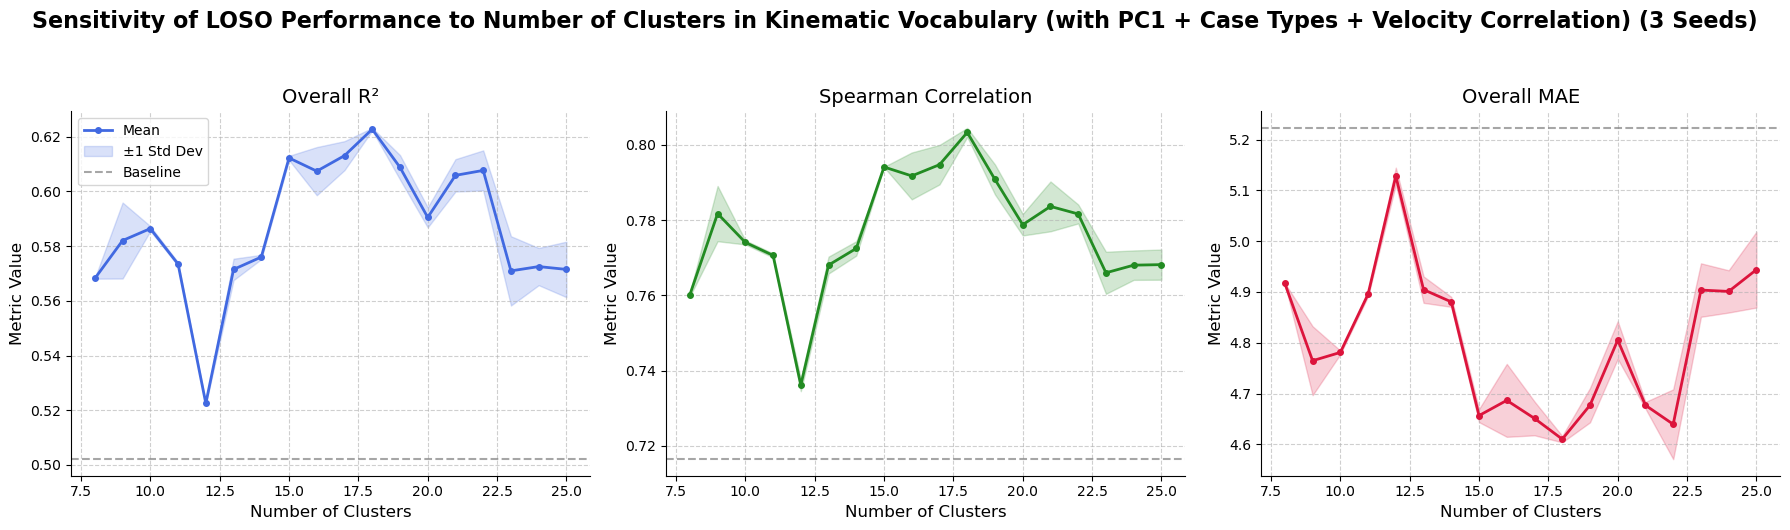

In [80]:
plot_sensitivity_results(cluster_range, results, title="Sensitivity of LOSO Performance to Number of Clusters in Kinematic Vocabulary (with PC1 + Case Types + Velocity Correlation)")

### Run it with k means fitten inside of losso folds for K=18

**Thesis Result**

In [ ]:
# with K = 18 !THESIS RESULT!
seed = 42
print('seed:', seed)
vocab = KinematicVocabulary(n_clusters=18, random_state=seed, model_type='kmeans', n_init=20,
                            feature_cols=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                            log_feats=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                            power_feats=None)


res = evaluator.evaluate_vocabulary(
    df_pc1_features,
    df_window,
    vocab,
    model=LassoCV(alphas=np.logspace(-1, 0.5, 30)),
    primary_features=pc1_features,
    bow_features=['SurgeMe_' + str(i) for i in range(18)],
    extra_features=['Case_1', 'Case_2', 'Case_3', 'Velocity corr.'],
    leakage_free=True,
    use_baseline=True,
)

summary = res['summary']
print_performance(summary, f"{n_cluster} Clusters - Results")

all_fold_centroids = res["fold_centroids"]

seed: 42


Vocabulary LOSO: 100%|██████████| 28/28 [01:27<00:00,  3.14s/it]

=== 25 Clusters - Results ===
MAE: 4.6548 ± 3.3804
Spearman R: 0.7958 and R²: 0.6180

